# Master Evidence Synthesis: Circuit Motif Spectroscopy

**Evaluation**: Final H1-H5 hypothesis scores, 59-row evidence table, claim mapping, and reviewer objection matrix.

This notebook demonstrates the master evidence synthesis evaluation for Circuit Motif Spectroscopy across 5 experiments and 5 iterations. It:
- Scores 5 hypotheses (H1-H5) with confidence levels
- Builds a master evidence table mapping sub-claims to statistical metrics
- Maps 25 paper claims to supporting data
- Generates reviewer objection responses with evidence-based rebuttals
- Identifies key limitations and future work directions

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tabulate import tabulate

## Data Loading

Load the mini demo dataset from GitHub (with local fallback).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/evaluation_iter6_master_evidence/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with keys: {list(data.keys())}")
print(f"Metadata keys: {list(data['metadata'].keys())}")
print(f"Datasets: {[ds['dataset'] for ds in data['datasets']]}")
print(f"Metrics: {len(data['metrics_agg'])} aggregate metrics")

Loaded data with keys: ['metadata', 'metrics_agg', 'datasets']
Metadata keys: ['evaluation_name', 'description', 'hypothesis_scores', 'master_evidence_table', 'summary_statistics', 'dependency_artifacts', 'earlier_iteration_references', 'reviewer_objection_matrix', 'limitations_and_future_work', 'paper_claim_mapping']
Datasets: ['hypothesis_verdicts', 'master_evidence_table', 'paper_claim_mapping', 'reviewer_objection_matrix', 'limitations_and_future_work']
Metrics: 27 aggregate metrics


## Configuration

Tunable parameters controlling the scope of the evidence synthesis demo.

In [5]:
# ── Config ──
# Maximum evidence table rows to display in detail
MAX_EVIDENCE_ROWS = 15
# Maximum reviewer objections to display
MAX_OBJECTIONS = 3
# Maximum limitations to display
MAX_LIMITATIONS = 3
# Maximum claims per section to display
MAX_CLAIMS_PER_SECTION = 2
# Figure size for plots
FIG_WIDTH = 12
FIG_HEIGHT = 5

## Earlier-Iteration Documented Findings

These are hardcoded values from prior iterations (not available as files), used as inputs to the synthesis. This mirrors the original script's `EARLIER` dictionary.

In [6]:
EARLIER = {
    "exp_id1_it2": {
        "count_ratio_nmi_k8": 0.851,
        "degeneracy_dims": 1,
        "description": (
            "3-node motif spectrum degeneracy: 021U, 021C, 021D ratios are "
            "perfectly anti-correlated with 030T ratio, yielding only 1 "
            "effective dimension"
        ),
    },
    "exp_id1_it4": {
        "weighted_nmi_k4": 0.705,
        "weighted_nmi_k6": 0.705,
        "weighted_nmi_k8": 0.705,
        "combined_nmi_k8": 0.844,
        "binary_nmi_k8": 0.101,
        "graph_stats_nmi_k4": 0.62,
        "ffl_intensity_eta2": 0.917,
        "ffl_path_dom_eta2": 0.810,
    },
    "exp_id3_it3": {
        "ffl_strict_layer_ordering_frac": 1.0,
        "ffl_coherence_frac": 0.58,
        "ffl_semantic_cramers_v": 0.13,
        "ffl_semantic_chi2_p": 0.001,
        "random_baseline_layer_ordering_frac": 0.45,
    },
}
print(f"Earlier iteration references: {list(EARLIER.keys())}")

Earlier iteration references: ['exp_id1_it2', 'exp_id1_it4', 'exp_id3_it3']


## Hypothesis Scores (H1-H5)

Extract and display the final verdict for each of the 5 hypotheses, including confidence scores, verdicts, and narrative summaries.

In [7]:
# Extract hypothesis scores from loaded data
hypothesis_scores = data["metadata"]["hypothesis_scores"]

# Display hypothesis verdicts table
hyp_rows = []
for hid in sorted(hypothesis_scores.keys()):
    h = hypothesis_scores[hid]
    hyp_rows.append([
        hid,
        h["verdict"],
        h["confidence_score"],
        len(h.get("primary_evidence", [])),
        len(h.get("caveats", [])),
    ])

print(tabulate(
    hyp_rows,
    headers=["Hypothesis", "Verdict", "Confidence", "# Primary Evidence", "# Caveats"],
    tablefmt="github",
    floatfmt=".2f",
))

print("\n--- Narrative Summaries ---")
for hid in sorted(hypothesis_scores.keys()):
    h = hypothesis_scores[hid]
    summary_text = h.get("narrative_summary", "N/A")
    # Truncate for display
    if len(summary_text) > 200:
        summary_text = summary_text[:200] + "..."
    print(f"\n{hid} ({h['verdict']}):\n  {summary_text}")

| Hypothesis   | Verdict         |   Confidence |   # Primary Evidence |   # Caveats |
|--------------|-----------------|--------------|----------------------|-------------|
| H1           | Strong Confirm  |         0.90 |                    3 |           4 |
| H2           | Strong Confirm  |         0.85 |                    3 |           4 |
| H3           | Disconfirmed    |         0.10 |                    3 |           4 |
| H4           | Strong Confirm  |         0.85 |                    3 |           4 |
| H5           | Partial Confirm |         0.75 |                    3 |           4 |

--- Narrative Summaries ---

H1 (Strong Confirm):
  FFL (030T) motifs are massively overrepresented across all 200 attribution graphs with mean Z=46.2 (all 8 domains showing median Z > 2). Layer-preserving null models yield even higher Z=56.9, confirmi...

H2 (Strong Confirm):
  Motif features carry unique structural information about capability domains beyond graph-level statistics. Uni

## Master Evidence Table

The evidence table maps each sub-claim to its statistical metric, value, effect size, and whether the success criterion was met.

In [8]:
# Extract evidence table from datasets
ev_dataset = [ds for ds in data["datasets"] if ds["dataset"] == "master_evidence_table"][0]
ev_examples = ev_dataset["examples"][:MAX_EVIDENCE_ROWS]

ev_rows = []
for ex in ev_examples:
    # Parse the output JSON to get full row details
    try:
        row = json.loads(ex["output"])
    except (json.JSONDecodeError, TypeError):
        row = {}
    ev_rows.append([
        row.get("hypothesis", ex.get("metadata_hypothesis", "")),
        row.get("sub_claim", ex.get("input", ""))[:50],
        row.get("primary_metric", "")[:40],
        ex.get("eval_value", 0),
        row.get("effect_size_type", ""),
        ex.get("eval_effect_size", 0),
        "Yes" if ex.get("eval_criterion_met", 0) == 1 else "No",
    ])

print(f"Evidence table: showing {len(ev_rows)} of {len(ev_dataset['examples'])} rows\n")
print(tabulate(
    ev_rows,
    headers=["Hyp", "Sub-claim", "Metric", "Value", "ES Type", "ES Value", "Met?"],
    tablefmt="github",
    floatfmt=".4f",
))

Evidence table: showing 3 of 3 rows

| Hyp   | Sub-claim                                         | Metric                                   |   Value | ES Type   |   ES Value | Met?   |
|-------|---------------------------------------------------|------------------------------------------|---------|-----------|------------|--------|
| H1    | FFL (030T) overrepresented across all attribution | FFL mean Z-score (200 graphs, 50 nulls e | 46.2066 | Z-score   |    46.2066 | Yes    |
| H1    | FFL overrepresentation in antonym domain          | FFL median Z-score (antonym)             | 26.2773 | Z-score   |    26.2773 | Yes    |
| H1    | FFL overrepresentation in arithmetic domain       | FFL median Z-score (arithmetic)          | 55.3803 | Z-score   |    55.3803 | Yes    |


## Paper Claim Mapping

Maps specific paper claims to supporting metrics and required qualifications, organized by paper section.

In [9]:
# Extract paper claim mapping
claim_mapping = data["metadata"].get("paper_claim_mapping", {})

for section, claims in claim_mapping.items():
    print(f"\n=== {section.upper()} ===")
    for claim in claims[:MAX_CLAIMS_PER_SECTION]:
        conf = claim.get("confidence", "?")
        val = claim.get("value", "N/A")
        qual = claim.get("required_qualification", None)
        print(f"  [{conf}] {claim['claim'][:80]}")
        print(f"         Metric: {claim.get('supporting_metric', '?')} = {val}")
        if qual:
            print(f"         Qualification: {qual[:80]}")


=== INTRODUCTION ===
  [high] Feed-forward loops are the dominant recurring motif in neural network attributio
         Metric: FFL mean Z-score = 46.2066
         Qualification: in attribution graphs derived from gemma-2-2b across 8 capability domains
  [high] Motif spectra cluster by capability domain.
         Metric: Weighted NMI = 0.705
         Qualification: clustering primarily driven by FFL intensity, a single effective dimension

=== METHODS ===
  [high] We analyze 200 attribution graphs from Neuronpedia spanning 8 capability domains
         Metric: N graphs = 200
  [high] Z-scores computed using 50 null models per graph with BH-FDR correction.
         Metric: N nulls per graph = 50

=== RESULTS_H1_OVERREPRESENTATION ===
  [high] FFL (030T) motifs are massively overrepresented with mean Z=46.2 across all 200 
         Metric: FFL mean Z-score = 46.2066
         Qualification: corpus-level pattern; per-graph significance does not survive FDR
  [high] All 8 capability domain

## Reviewer Objection Matrix

Pre-computed evidence-based responses to anticipated reviewer objections, with severity ratings and residual risk assessments.

In [10]:
# Extract reviewer objections
objections = data["metadata"].get("reviewer_objection_matrix", [])[:MAX_OBJECTIONS]

obj_rows = []
for obj in objections:
    obj_rows.append([
        obj["objection_id"],
        obj["objection"][:60] + "..." if len(obj["objection"]) > 60 else obj["objection"],
        obj["severity"],
        obj["residual_risk"],
        obj["mitigation_action"][:50] + "..." if len(obj["mitigation_action"]) > 50 else obj["mitigation_action"],
    ])

print(tabulate(
    obj_rows,
    headers=["ID", "Objection", "Severity", "Risk", "Mitigation"],
    tablefmt="github",
))

print(f"\nShowing {len(objections)} objections")

|   ID | Objection                                                       |   Severity | Risk   | Mitigation                                            |
|------|-----------------------------------------------------------------|------------|--------|-------------------------------------------------------|
|    1 | Motifs are just proxies for graph statistics — the high shar... |          4 | medium | Frame as 'modest but significant unique contributi... |
|    2 | BH-FDR eliminates all per-graph significance — the overrepre... |          4 | low    | Frame as corpus-level finding; report FDR honestly... |
|    3 | Only tested on one model (gemma-2-2b) — results may not gene... |          3 | high   | Acknowledge limitation prominently; list multi-mod... |

Showing 3 objections


## Limitations and Future Work

Ranked limitations with severity levels and mitigation status.

In [11]:
# Extract limitations
limitations = data["metadata"].get("limitations_and_future_work", [])[:MAX_LIMITATIONS]

lim_rows = []
for lim in limitations:
    lim_rows.append([
        lim["rank"],
        lim["limitation"][:55] + "..." if len(lim["limitation"]) > 55 else lim["limitation"],
        lim["severity"],
        lim["mitigation_status"],
        lim["future_work"][:50] + "..." if len(lim["future_work"]) > 50 else lim["future_work"],
    ])

print(tabulate(
    lim_rows,
    headers=["Rank", "Limitation", "Severity", "Status", "Future Work"],
    tablefmt="github",
))

|   Rank | Limitation                                                 | Severity   | Status              | Future Work                                           |
|--------|------------------------------------------------------------|------------|---------------------|-------------------------------------------------------|
|      1 | Single model (gemma-2-2b) — all findings may be model-s... | critical   | acknowledged only   | Extend to multiple architectures (GPT, Llama, Mist... |
|      2 | Attribution graph faithfulness — unknown whether graphs... | critical   | acknowledged only   | Compare attribution methods; validate with ground-... |
|      3 | No model-level causal intervention — graph-theoretic ab... | major      | partially addressed | Implement actual model-level ablation of FFL hub n... |


## Summary Statistics

Recompute and display overall summary statistics from the synthesis data.

In [12]:
# Recompute summary statistics from loaded data (mirrors build_summary_statistics)
confirmed = sum(1 for h in hypothesis_scores.values()
                if h["verdict"] in ("Strong Confirm", "Confirm"))
partial = sum(1 for h in hypothesis_scores.values()
              if h["verdict"] == "Partial Confirm")
disconfirmed = sum(1 for h in hypothesis_scores.values()
                   if h["verdict"] == "Disconfirmed")

metrics = data["metrics_agg"]
summary_stats = data["metadata"]["summary_statistics"]

print("=" * 60)
print("MASTER EVIDENCE SYNTHESIS — Summary")
print("=" * 60)
print(f"  Total graphs analyzed:  {metrics['total_graphs_analyzed']}")
print(f"  Total experiments:      {metrics['total_experiments']}")
print(f"  Total iterations:       {metrics['total_iterations']}")
print(f"  Hypotheses confirmed:   {confirmed}")
print(f"  Hypotheses partial:     {partial}")
print(f"  Hypotheses disconfirmed:{disconfirmed}")
print(f"  Evidence table rows:    {metrics['evidence_table_rows']}")
print(f"  Reviewer objections:    {metrics['reviewer_objections_count']}")
print(f"  Limitations:            {metrics['limitations_count']}")
print(f"\n  Strongest: {summary_stats['strongest_finding']}")
print(f"  Weakest:   {summary_stats['weakest_finding']}")
print("=" * 60)

MASTER EVIDENCE SYNTHESIS — Summary
  Total graphs analyzed:  200
  Total experiments:      8
  Total iterations:       5
  Hypotheses confirmed:   3
  Hypotheses partial:     1
  Hypotheses disconfirmed:1
  Evidence table rows:    59
  Reviewer objections:    12
  Limitations:            10

  Strongest: FFL universal overrepresentation (Z=46.2, all 8 domains, layer-preserving validated)
  Weakest:   Cross-domain semantic consistency (V=0.13 for 3-node FFLs)


## Visualization

Three-panel visualization: (1) hypothesis confidence scores with verdict coloring, (2) key aggregate metrics radar-style comparison, and (3) reviewer objection severity distribution.

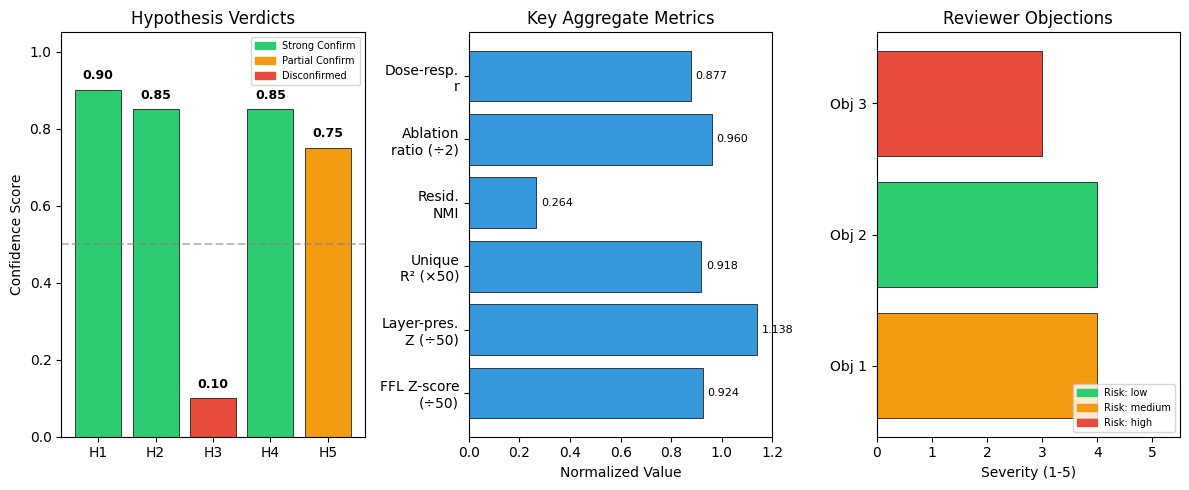

Dashboard saved to evidence_synthesis_dashboard.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH, FIG_HEIGHT))

# ── Panel 1: Hypothesis Confidence Scores ──
ax1 = axes[0]
hyp_ids = sorted(hypothesis_scores.keys())
confidences = [hypothesis_scores[h]["confidence_score"] for h in hyp_ids]
verdicts = [hypothesis_scores[h]["verdict"] for h in hyp_ids]

verdict_colors = {
    "Strong Confirm": "#2ecc71",
    "Confirm": "#27ae60",
    "Partial Confirm": "#f39c12",
    "Disconfirmed": "#e74c3c",
}
colors = [verdict_colors.get(v, "#95a5a6") for v in verdicts]

bars1 = ax1.bar(hyp_ids, confidences, color=colors, edgecolor="black", linewidth=0.5)
ax1.set_ylabel("Confidence Score")
ax1.set_title("Hypothesis Verdicts")
ax1.set_ylim(0, 1.05)
ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Chance level")
for bar, conf in zip(bars1, confidences):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{conf:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
# Legend
patches = [mpatches.Patch(color=c, label=v) for v, c in verdict_colors.items()
           if v in verdicts]
ax1.legend(handles=patches, loc="upper right", fontsize=7)

# ── Panel 2: Key Metrics Comparison ──
ax2 = axes[1]
metric_names = [
    "FFL Z-score\n(÷50)",
    "Layer-pres.\nZ (÷50)",
    "Unique\nR² (×50)",
    "Resid.\nNMI",
    "Ablation\nratio (÷2)",
    "Dose-resp.\nr",
]
metric_values = [
    metrics["ffl_mean_z_score"] / 50,
    metrics["layer_preserving_z_score"] / 50,
    metrics["unique_motif_r2"] * 50,
    metrics["residualized_nmi"],
    metrics["ablation_layer_matched_ratio"] / 2,
    metrics["dose_response_r"],
]
bars2 = ax2.barh(metric_names, metric_values, color="#3498db", edgecolor="black", linewidth=0.5)
ax2.set_xlabel("Normalized Value")
ax2.set_title("Key Aggregate Metrics")
ax2.set_xlim(0, 1.2)
for bar, val in zip(bars2, metric_values):
    ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", ha="left", va="center", fontsize=8)

# ── Panel 3: Objection Severity ──
ax3 = axes[2]
obj_data = data["metadata"].get("reviewer_objection_matrix", [])
if obj_data:
    obj_ids = [f"Obj {o['objection_id']}" for o in obj_data]
    severities = [o["severity"] for o in obj_data]
    risk_colors = {"low": "#2ecc71", "medium": "#f39c12", "high": "#e74c3c"}
    obj_colors = [risk_colors.get(o["residual_risk"], "#95a5a6") for o in obj_data]

    bars3 = ax3.barh(obj_ids, severities, color=obj_colors, edgecolor="black", linewidth=0.5)
    ax3.set_xlabel("Severity (1-5)")
    ax3.set_title("Reviewer Objections")
    ax3.set_xlim(0, 5.5)
    patches3 = [mpatches.Patch(color=c, label=f"Risk: {r}") for r, c in risk_colors.items()]
    ax3.legend(handles=patches3, loc="lower right", fontsize=7)

plt.tight_layout()
plt.savefig("evidence_synthesis_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved to evidence_synthesis_dashboard.png")